# CSC-321: Data Mining and Machine Learning
# Jordin Palmeri

## Assignment 5: Working with real data

For this notebook, you'll be using a mix of your own implementations of ML code, and scikit-learn implementations. Make sure you're clear on where and when each should be used.

**FORMATTING NOTE:** What follows is a series of experiements, using different datasets, with different numbers of instances and features. You're going to end up with a long notebook containing all kinds of print statements and cells containing numbers. It is VERY easy to get confused. I strongly suggest the following:
- use descriptive variable names. If your variable contains output from zeroR, call it something appropriate
- be REALLY careful re-using variable names. X_train can get seriously overused, in which case it's easy to confuse what the contents of that variable are. Which data set? Normalized? Different from X_test, or the same?
- minimize output. This is tricky, given that you should ALWAYS do sanity checks on your data (using functions like .info(),.head() and .describe() that I introduce below). I recommend performing them, but then comment out the print statement. Copy important information into TEXT cells. Once you've checked your data you don't have to always display it. THINK about what you need to display vs. what you don't.
- Keep what output you have COMPACT. Don't overdo it, squashing things up together, but be mindful of spacing, like I suggest with the output of your SGD function below.
- Feel free, once you are convinced things like SGD work, to replace the constant output of epoch/learning rate etc. I edit mine to print just TWICE. Once at the start (epoch 0), and once at the end.
- You don't need to graph learning rate everytime. It's useful when optimizing parameters, but we're not really doing that now.
- CREATE new cells when appropriate. I often find it beneficial to have new cells for each experiment.
- ALWAYS print the following information at the top of any cell when you run an experiment: Data set name, number of instances, number of features
- ALWAYS include algorithm name when printing a result.

In grading your notebook, I WILL BE ATTENTIVE TO LAYOUT AND PRESENTATION OF RESULTS. If you're just dumping numbers to the screen you're going to have a bad time. Make your output look good, but more importantly, make it easy to compare numbers.

There are cells below where you have to edit things, or write things, and there are cells where you have to just run them, and observe the results. I recommend running this notebook one cell at a time, and making sure you are clear on what the cell is doing, and why.



### Part 1: Loading Data

We're going to make use of the pandas library (because [pandas are cute](https://www.youtube.com/shorts/Po-nVAMaA8c)) to load data and to get a quick overview. For the first data set, I'm going to walk you through some typical commands. Note that in your work, you don't always have to print these out or display them, it's just good practice as you're working through a problem. I have lost track of the number of times I have sliced a data set, and left behind more instances or features than I intended to.

For reference:
- [Pandas](https://pandas.pydata.org/)


Run the following cell.

In [ ]:
import pandas as pd

# Load the data

insurance_data = pd.read_csv('https://raw.githubusercontent.com/nixwebb/CSV_Data/master/insurance.csv')

# Show the head - just the first 5 entries by default

insurance_data.head()


,108,392.5
0,19,46.2
1,13,15.7
2,124,422.2
3,40,119.4
4,57,170.9


Look at the data above. The column headings should look weird. That's because pandas decided to treat the first row as column headings. I can prevent that by supplying my own column headings, which I demonstrate below.

I chose X and y. While this is illustrative for this example, it's bad. Why?
Those aren't the actual column headings. What are they? You'll need to find out by looking at the information for the data set. I include a link, below. You should ALWAYS know what the data represents.

It's a good idea in pandas to use descriptive but short names for your columns, as we are going to use them for indexing. I would avoid using spaces in column names, and use underscores instead: e.g. 'birth date', should be 'birth_date' or 'DOB'. That said, also avoid acronyms that ONLY mean something to you.

(a) Edit the column headings below, currently defined as 'X' and 'y' in the names variable, to be more descriptive based on your understanding of the data described below.

- [Insurance Data](http://college.cengage.com/mathematics/brase/understandable_statistics/7e/students/datasets/slr/frames/slr06.html)

In [ ]:

# Reading in the data again, but with slightly more descriptive headings.

insurance_data = pd.read_csv('https://raw.githubusercontent.com/nixwebb/CSV_Data/master/insurance.csv',names=['num_claims','total_payment(Kronor)'])
insurance_data.head()

,num_claims,total_payment(Kronor)
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4


Now that I have column headings, I can use them in pandas. For example, if I wanted to extract just the column called 'X' into a new data frame, I would write:

new_df = insurance_data['X'].copy()

The .copy() is so that I make a new copy of the **values**, rather than copies of the references to values in a data frame, which can have unintended side effects. Dataframes are MUTABLE - any change I make to the contents of a dataframe can be permanent.


The next few cells are showing typical information we want to know about our data. We can use the .info() method, to see counts of instances, columns, and data types.

In [ ]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_claims             63 non-null     int64  
 1   total_payment(Kronor)  63 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


And we can use .describe() to get more detailed information.
- The count is the number of entries for that column.
- The mean is the average value.
- The std is the value for one standard deviation
  - i.e. in our y column, the mean is 98.19, and the std is 87.33
  - That means that one standard deviation either side of the mean ranges from 10.86 to 185.52
  - We can expect around 68% of our data to
fall in this range, IF our data is normally distributed.
- The min and the max are...well, I think you know
- The quartile values (25/50/75) show what the value is at those markers
  - i.e. 25% of all our values of X are below 7.5

In [ ]:
insurance_data.describe()

,num_claims,total_payment(Kronor)
count,63.000000,63.000000
mean,22.904762,98.187302
std,23.351946,87.327553
min,0.000000,0.000000
25%,7.500000,38.850000
50%,14.000000,73.400000
75%,29.000000,140.000000
max,124.000000,422.200000


Let's take a graphical look at the data. As there are only two features, we can plot one against the other, just as you did with the data in assignment 2.



(b) Get the values from the dataframe. Remember that you can use .values on a dataframe to get all of the data as a numpy array. Split the insurance_values into 2 datasets, X_values and y_values. The X_values are the contents of the first column (whatever you've called it) and the y_values are the contents of the second column. It's ALWAYS a good idea to print out the number of instances (rows) and the number of features (columns) to make sure you're not accidentally messing with things. I've done that for you. If you're slicing is correct, the y values will have the SAME number of instances. It doesn't have a column value - because it's a one dimensional vector.

(c) Plot X_values against y_values so we can visualize the instances. Make each instance a blue triangle. Label the axes appropriately, using the same names as your column headings from a.


This is the insurance data training set. It has 63 instances, and 1 input feature.


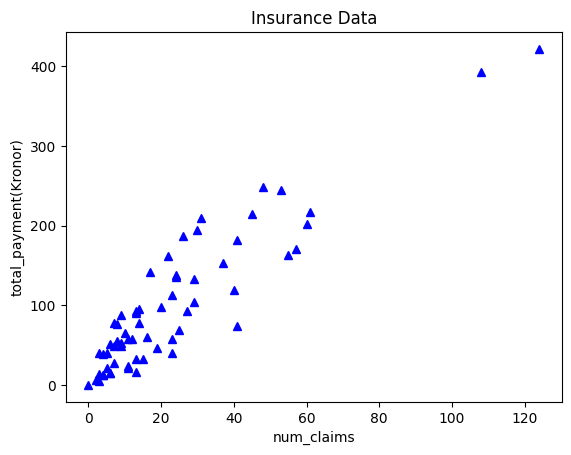

In [ ]:
# Separate your data

X_values = insurance_data['num_claims'].values
y_values = insurance_data['total_payment(Kronor)'].values

rows = X_values.shape[0]
print("This is the insurance data training set. It has", rows, "instances, and 1 input feature.")

import matplotlib.pyplot as plt

# Plot your graph
plt.plot(X_values, y_values, 'b^')
plt.xlabel('num_claims')
plt.ylabel('total_payment(Kronor)')
plt.title('Insurance Data')
plt.show()



### Part 2: Learn what we can we learn

If you've done it right, you should have a visual sense of a relationship in the data between the X and y values. That tells us what kind of model we might want to learn.

We'll start by using a training and test set that are the same, so create X_train and y_train, and X_test and y_test as copies of X_values and y_values. I recommend using the .copy() function when taking copies of data.


(d) Copy your linear regression code from Assignment 2 below. Run simple linear regression on this data, to get predicted y values for X_test.

(e) Copy your zeroR code from Assignment 2. Run zeroR on the data, to get predicted y values.

(f) Plot both zeroR and slr predicted relationships as lines (red for slr, green for zeroR), as well as the blue data points above.

(g) Calculate and print RMSE for both zeroR and slr, compared to y_test.




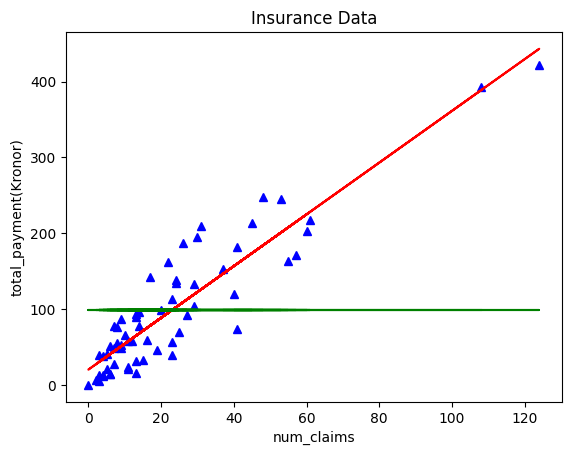

SLR RMSE: 35.37
zeroR RMSE: 86.63


In [ ]:
# Add code here

linear_X_train = X_values.copy()
linear_y_train = y_values.copy()
linear_X_test = X_values.copy()
linear_y_test = y_values.copy()


# Simple Linear Regression
def SLR(X_train, y_train, X_test):
  labels = coefficients(X_train, y_train)
  b0 = labels[0]
  b1 = labels[1]

  predictions = []
  for value in X_test:
    predictions.append(b0 + b1 * value)

  return predictions

def coefficients(x_values, y_values):
  covar = covariance(x_values,y_values)
  var_x = variance(x_values)

  b1 = covar / var_x

  mean_x = mean(x_values)
  mean_y = mean(y_values)

  b0 = mean_y - (b1 * mean_x)
  return [b0, b1]

def mean (lst):
  if len(lst) == 0:
    return None
  return sum(lst) / len(lst)


def variance(values):
  mean_val = mean(values)
  total_var = 0

  for v in values:
    total_var += (v - mean_val)**2

  return total_var

def covariance(x_values, y_values):
  x_mean = mean(x_values)
  y_mean = mean(y_values)

  total = 0
  for i in range(len(x_values)):
    total += (x_values[i] - x_mean) * (y_values[i] - y_mean)
  return total

linear_predictions = SLR(linear_X_train, linear_y_train, linear_X_test)


# ZeroR
def zeroRR(y_train, X_test):
  mean_y = mean(y_train)
  preditions = [mean_y for i in X_test]

  return preditions

zeroR_predictions = zeroRR(linear_y_train, linear_X_test)


# Plotting

plt.plot(linear_X_train, linear_y_train, 'b^', linear_X_train, linear_predictions, 'r-', linear_X_train, zeroR_predictions, 'g-')
plt.xlabel('num_claims')
plt.ylabel('total_payment(Kronor)')
plt.title('Insurance Data')
plt.show()


# RMSE
def RMSE(actual, predicted):
  error = 0

  for i in range(len(actual)):
    error += (predicted[i] - actual[i])**2

  return (error / len(predicted))**0.5


SLR_RMSE = RMSE(linear_y_test, linear_predictions)
zeroR_RMSE = RMSE(linear_y_test, zeroR_predictions)

print(f"SLR RMSE: {SLR_RMSE:.2f}")
print(f"zeroR RMSE: {zeroR_RMSE:.2f}")

(h) To reinforce the use of scikit-learn, go ahead and REDO the experiment above, using the appropriate models from the sklearn library. You're going to need:
- Linear Regression (NOT the SGD regressor)
- zeroR (the Dummy Regressor)
- the RMSE metric (you can import root_mean_squared_error from the sklearn.metrics module)

Fit each model, and evaluate the predictions. You should get the same scores as you do with your own code above.

Scikit-learn Linear Regression RMSE: 35.37
Scikit-learn ZeroR RMSE: 86.63


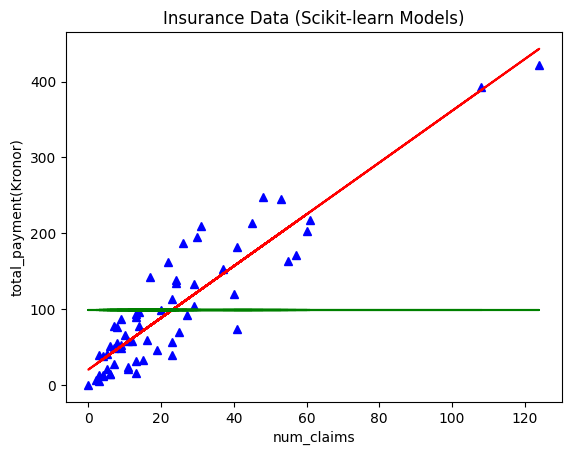

In [ ]:
# Add your code here
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np

# Reshape X
X_train_linear_sk = linear_X_train.reshape(-1, 1)
y_train_linear_sk = linear_y_train
X_test_linear_sk = linear_X_test.reshape(-1, 1)
y_test_linear_sk = linear_y_test

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_linear_sk, y_train_linear_sk)

linear_predictions_sklearn = lin_reg.predict(X_test_linear_sk)

# ZeroR
zeroR_model = DummyRegressor(strategy='mean')
zeroR_model.fit(X_train_linear_sk, y_train_linear_sk)

zeroR_predictions_sklearn = zeroR_model.predict(X_test_linear_sk)

# RMSE
SLR_RMSE_sklearn = root_mean_squared_error(y_test_linear_sk, linear_predictions_sklearn)
zeroR_RMSE_sklearn = root_mean_squared_error(y_test_linear_sk, zeroR_predictions_sklearn)

print(f"Scikit-learn Linear Regression RMSE: {SLR_RMSE_sklearn:.2f}")
print(f"Scikit-learn ZeroR RMSE: {zeroR_RMSE_sklearn:.2f}")

# plot

plt.plot(X_train_linear_sk, y_train_linear_sk, 'b^')
plt.plot(X_train_linear_sk, linear_predictions_sklearn, 'r-')
plt.plot(X_train_linear_sk, zeroR_predictions_sklearn, 'g-')
plt.xlabel('num_claims')
plt.ylabel('total_payment(Kronor)')
plt.title('Insurance Data (Scikit-learn Models)')
plt.show()




(i) In the text box, INTERPRET these scores for me. **This is the important bit.** Can you tell me what these RMSE scores REALLY mean with respect to this data? To answer that, you have to understand the insurance data. Refer back to the link I gave you for the data earlier. ALSO tell me if you think we can do better? Do you believe there are other models that will generate LOWER error scores over this data?

REMEMBER: We're predicting y values. What are those? Remember too that RMSE returns you the average error over all predictions, and that the error is expressed in the same units as the thing we're predicting. What does this tell us? Tell me about the practical results of the algorithms we just used - how is one better than the other in real terms?


The Linear Regression model produces an average prediction error of about 35 thousand Kronor, compared to 87 thousand Kronor for the simple mean-predicting ZeroR model.

This means that the linear model is a far better fit for the data.

However, since insurance payments depend on more than just the number of claims, adding more relevant features would likely yield even lower RMSE scores and better predictive performance.

## Better Understanding:
- Linear regression is doing better
  - Our ZeroR for Swedish Kronor has an average error of 86.63 thousand Kronor wrong
  - And our Linear Model has an average error of 35.37 thousand Kronor wrong
- For this data there is NO better model



### Part 3: Let's get normal(ized)

When working with data that has multiple inputs, we often want to normalize the data, so that it's all on the same scale (usually 0-1, using min-max normalization).

There are TWO main reasons to do this:

(A) normalization often helps alorithms do better, particularly algorithms where estimation or optimization is involved (like SGD).

(B) any resulting coefficients will be on the same scale, so we can compare them directly, where bigger (absolute) values have more impact


We're going to test (A), first.

Below I'm going to use pandas to load a different dataset. This one is about wine. You can [read a bit about the data](http://archive.ics.uci.edu/ml/datasets/Wine+Quality). The class in this data is a numerical value that represents the quality of the wine, like a start rating, in the range 0-10. Let's first try multivariate linear regression (because there's more than one input feature), and see if we can predict that value.

(a) Choose meaningful headings for the columns, and replace the uniformative strings, below.


In [ ]:
labels = ['fixed_acidity','volatile_acidity','citric_acid','residual_sugar',
          'chlorides','free_sulfur_dioxide','total_sulfur_dioxide',
          'density','pH','sulphates','alcohol','quality']



wine_data = pd.read_csv('https://raw.githubusercontent.com/nixwebb/CSV_Data/master/winequality-white.csv',names=labels)

wine_data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


(b) Get a little more information about our data, using the .describe() method.

Pay attention to the values for each feature. Note that they are NOT on the same scale (and look at the min and max values for each). All the features are numerical, including the last feature, which is a representation of a quality of wine, on the scale 0-10.

Also note how many features (columns) there are, and how many instances. Print both.

In [ ]:
# Call describe here
wine_data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [ ]:
rows, cols = wine_data.shape
print("Number of instances (rows):", rows)
print("Number of features (columns):", cols - 1)

Number of instances (rows): 4898
Number of features (columns): 11


Because there are lots of features (more than 2) it makes no sense to plot this data on a graph - as humans we find it quite hard to visualize more than 3 dimensions (and each feature is a dimension).

(c) Instead let's get straight to learning. I want to use three scikit-learn models first this time:
- The SGD regressor
- Linear Regression
- ZeroR

You need to:
- Get your X_values and y_values, as you did for Part 2, above, rembering that there are more than 1 inout feature now
- Create X_train, y_train, and X_test and y_test (for now, we're continuing to use the same data for training and testing)
- Fit your models
- Evaluate your models using RMSE

Two of the RMSE scores should look....reasonable. The third...not so much. It's ok, that was expected. Tell me which one is off. I wonder why that happened?


In [ ]:
# Write code here

import math
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

X_values_wine = wine_data.drop('quality', axis=1).values
y_values_wine = wine_data['quality'].values


X_train_wine = X_values_wine.copy()
y_train_wine = y_values_wine.copy()
X_test_wine = X_values_wine.copy()
y_test_wine = y_values_wine.copy()


# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_wine, y_train_wine)
linear_predictions = lin_reg.predict(X_test_wine)

# SGD Regressor
sgd_reg = SGDRegressor(max_iter=200)
sgd_reg.fit(X_train_wine, y_train_wine)
sgd_predictions = sgd_reg.predict(X_test_wine)

# ZeroR (Dummy Regressor)
zeroR = DummyRegressor(strategy='mean')
zeroR.fit(X_train_wine, y_train_wine)
zeroR_predictions = zeroR.predict(X_test_wine)


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

sgd_rmse_wine = rmse(y_test_wine, sgd_predictions)
lr_rmse_wine = rmse(y_test_wine, linear_predictions)
zr_rmse_wine = rmse(y_test_wine, zeroR_predictions)


print(f"Linear Regression RMSE: {lr_rmse_wine:.2f}")
print(f"SGD Regressor RMSE: {sgd_rmse_wine:.2f}")
print(f"ZeroR RMSE: {zr_rmse_wine:.2f}")

Linear Regression RMSE: 0.75
SGD Regressor RMSE: 3471211380216.93
ZeroR RMSE: 0.89


SGD is way off because it iteratively updates weights, but the features are not normalized. So, the RMSE calculation is a bit wonky.

When we fit the models, above. We got some properties of the models. For instance, we know that the [linear regression model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) has built in properties called .intercept_ and .coef_, that correspond to our b0, and b1...bN coefficients - the slope.

(d) Take a look at the coefficients stored in .coef_, and print them out, alongside the name of the feature they apply to. The names of those features should be stored in the labels variable we created earlier. The order of the coefficients and the label names will be the same.

In [ ]:
# Look at coefs here

print("Coefficients for Linear Regression:")
for i in range(len(labels) - 1):
  print(f"   {labels[i]}: {lin_reg.coef_[i]:.3f}")


Coefficients for Linear Regression:
   fixed_acidity: 0.066
   volatile_acidity: -1.863
   citric_acid: 0.022
   residual_sugar: 0.081
   chlorides: -0.247
   free_sulfur_dioxide: 0.004
   total_sulfur_dioxide: -0.000
   density: -150.284
   pH: 0.686
   sulphates: 0.631
   alcohol: 0.193


(e) NOW choose the THREE largest coefficient values, and write the names of the features they correspond to in a bulleted list, below. REMEMBER - size is absolute - so large negative scores count.

#### Most valuable features (Un-normalized)

*   Density
*   volatile_acidity
*   pH





BUT there were different ranges for the feature values (look back at .describe). We want to NORMALIZE this data, to make learning easier for the algorithm, and so that we can realistically compare things like coefficient values.

The steps to do that are below.

We're going to use min-max normalization, that works by:

normalized value = (value - minOfFeature) / (maxOfFeature - minOfFeature)

We're going to use the sklearn.preprocessing library to help us. I've done most of the work, you just need to extract the X_values and the y_values from the data. I always print out the shape of my data as a sanity check that I haven't lost anything.

(f) Extract the wine values from the wine data frame, and then slice out the X_values and y_values from the numpy array of values. Check that the number of instances and features matches what you expect looking at the output in the cell above. NOTE. You're welcome to use the X_values you already sliced out of the wine data frame for the first part of this section, above. BUT I almost always start from scratch, to make sure I'm not contaminating my data.

Then see how I apply the minmax scaler below. The transform function works on my data to perform normalization, and I can apply it to any new incoming data. But ONLY if that data has the same number of features as the data I used here! You can read more at:

- [MinMax Scaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Extract the values from the pandas dataframe

wine_values = wine_data.values

X_values = wine_values[:, :-1]
y_values = wine_values[:, -1]


# Get the shape, and print meaningful things
# Make sure this agrees with the decribe method, above

rows,cols = X_values.shape
print("This is the wine data set. It has", rows, "instances, and it has", cols, "input features.\n")

# Show the first instance

print("The first instance looks like:")
print(X_values[0])
print()

# Load and fit the scaler

scaler = MinMaxScaler()
scaler.fit(X_values)

# Use some attributes of the scaler to show min and max values per feature
# Note these should align with the information from the pandas .describe
# method, used above

print("MAX values:",scaler.data_max_)
print("MIN values:",scaler.data_min_)
print()

# Transform our X_values, so that data is now scaled
# Note we can apply this transform to any data, including new data
# and it will preserve the min and max values given above

X_values = scaler.transform(X_values)

# Take another look at tha first instance that should now be
# normalized

print("After normalization, the first instance looks like:")
print(X_values[0])


This is the wine data set. It has 4898 instances, and it has 11 input features.

The first instance looks like:
[7.000e+00 2.700e-01 3.600e-01 2.070e+01 4.500e-02 4.500e+01 1.700e+02
 1.001e+00 3.000e+00 4.500e-01 8.800e+00]

MAX values: [1.42000e+01 1.10000e+00 1.66000e+00 6.58000e+01 3.46000e-01 2.89000e+02
 4.40000e+02 1.03898e+00 3.82000e+00 1.08000e+00 1.42000e+01]
MIN values: [3.8000e+00 8.0000e-02 0.0000e+00 6.0000e-01 9.0000e-03 2.0000e+00
 9.0000e+00 9.8711e-01 2.7200e+00 2.2000e-01 8.0000e+00]

After normalization, the first instance looks like:
[0.30769231 0.18627451 0.21686747 0.30828221 0.10682493 0.14982578
 0.37354988 0.26778485 0.25454545 0.26744186 0.12903226]


Now that we've normalized the data, let's retry the learning tasks above. As usual, you'll need to create X_train and y_train sets, and X_test and y_test sets that are copies of X_values and y_values.

(g) Reapply the three algorithms, Linear Regression, SGD Regression and zeroR, to the normalized data. Predict y values. Calculate RMSE. Compare RMSE, both amongst the algorithms here, and to the RMSE values for the un-normalized data. Interpret the results for me. What do they really mean with respect to this data?


In [ ]:
# Apply the algorithms here

X_train_wine = X_values.copy()
y_train_wine = y_values.copy()
X_test_wine = X_values.copy()
y_test_wine = y_values.copy()

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_wine, y_train_wine)
linear_predictions = lin_reg.predict(X_test_wine)

# SGD Regressor
sgd_reg = SGDRegressor(max_iter=200)
sgd_reg.fit(X_train_wine, y_train_wine)
sgd_predictions = sgd_reg.predict(X_test_wine)

# ZeroR (Dummy Regressor)
zeroR = DummyRegressor(strategy='mean')
zeroR.fit(X_train_wine, y_train_wine)
zeroR_predictions = zeroR.predict(X_test_wine)


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

sgd_rmse_wine = rmse(y_test_wine, sgd_predictions)
lr_rmse_wine = rmse(y_test_wine, linear_predictions)
zr_rmse_wine = rmse(y_test_wine, zeroR_predictions)


print(f"Linear Regression RMSE: {lr_rmse_wine:.2f}")
print(f"SGD Regressor RMSE: {sgd_rmse_wine:.2f}")
print(f"ZeroR RMSE: {zr_rmse_wine:.2f}")

Linear Regression RMSE: 0.75
SGD Regressor RMSE: 0.78
ZeroR RMSE: 0.89


  - Normalization had little effect on models that are not scale-sensitive (like Linear Regression and ZeroR).

  - It had a major effect on the SGD Regressor, improving it from a completely unusable model to one that performs nearly as well as Linear Regression.

  - Overall, this confirms that scaling features is essential when using optimization-based models such as SGD.

#### Most valuable features (normalized)

(h) Those scaled coefficients mean we can now DIRECTLY compare them to each other - bigger coefficients MUST have more impact on the slope of the line we create.  Print (NICELY) the feature names, and their associated coefficient values, this time from the SGD Regressor. Write your three top performing features, and tell me if they are different to the un-normalized data, above.


In [ ]:
print("Coefficients for Linear Regression:")
for i in range(len(labels) - 1):
  print(f"   {labels[i]}: {lin_reg.coef_[i]:.3f}")

Coefficients for Linear Regression:
   fixed_acidity: 0.681
   volatile_acidity: -1.900
   citric_acid: 0.037
   residual_sugar: 5.313
   chlorides: -0.083
   free_sulfur_dioxide: 1.071
   total_sulfur_dioxide: -0.123
   density: -7.795
   pH: 0.755
   sulphates: 0.543
   alcohol: 1.200




*   Density
*   Residual_Sugar
*   Volatile_acidity

Residual sugar went from being one of the least significant features, to now being the second most important.


### Part 4: Something from the buffet?

Let's see how well you perform at selecting features. I asked you in part (h) above to pick 3 features using the coefficient scores above. When you loaded the data into pandas, you should have named your features something sensible. You should be able to take those string names of the top 3 absolute coefficients gtom (h), and replace them in my code below. I'll take those string names, and copy ONLY those columns out of the original wine data frame, along with the class value - the last one in the table.

(i) You need to rescale the data, because we're taking a copy of the unscaled data from the original data frame. Extract the values from the new data frame, create X and y value arrays, and scale the X values using the same process as above. You need to create a new scaler, because there are now a different number of features.

(j) Then call the SGDRegressor on this smaller, three feature data set. Collect the predicted values from this smaller model. Show the RMSE value.

(k) Compare the RMSE score for THIS experiment, with the previous one with all the features. What's the difference? What did we learn? Tell me in a text box. ALSO - tell me about this experiment as a whole. Did it seem reasonable? Was using linear regression as an approach (no matter if it's least squares or SGD based, they are both linear regression) a good idea? Are there alternatives? I want your thoughts and impressions.

In [ ]:
feature1 = 'density'
feature2 = 'residual_sugar'
feature3 = 'volatile_acidity'
feature4 = 'quality' # This one MUST be the name of your class column

reduced_wine = wine_data[[feature1,feature2,feature3,feature4]].copy()

# Get the values from the data above, and slice out the X_values and y_values

values = reduced_wine.values
X_values_reduced = values[:, :-1]
y_values_reduced = values[:, -1]


# Get the shape, and print meaningful things

rows, cols = X_values_reduced.shape
print(f"This reduced dataset has {rows} instances and {cols} input features.\n")

print("The first instance looks like:")
print(X_values_reduced[0])
print()


# Call the scaler, then run the experiments

scaler = MinMaxScaler()
scaler.fit(X_values_reduced)
X_values_reduced = scaler.transform(X_values_reduced)

print("After normalization, the first instance looks like:")
print(X_values_reduced[0])
print()


X_train_reduced = X_values_reduced.copy()
y_train_reduced = y_values_reduced.copy()
X_test_reduced = X_values_reduced.copy()
y_test_reduced = y_values_reduced.copy()


sgd_reg_reduced = SGDRegressor(max_iter=200)
sgd_reg_reduced.fit(X_train_reduced, y_train_reduced)
predictions_reduced = sgd_reg_reduced.predict(X_test_reduced)

rmse_reduced = math.sqrt(mean_squared_error(y_test_reduced, predictions_reduced))
print(f"SGD Regressor RMSE (3 features): {rmse_reduced:.2f}")

This reduced dataset has 4898 instances and 3 input features.

The first instance looks like:
[ 1.001 20.7    0.27 ]

After normalization, the first instance looks like:
[0.26778485 0.30828221 0.18627451]

SGD Regressor RMSE (3 features): 0.87


After reducing the dataset to only three features the SGD Regressor achieved an RMSE of 0.87. This is slightly higher than the RMSE of 0.78 we obtained when using all 11 features. But it also only slightly outperformed zeroR with an RMSE of 0.89.

This means that while these three features are indeed important predictors of wine quality, the remaining features still contribute valuable information that helps the model make more accurate predictions.

Overall, the experiment was reasonable because it tested whether a smaller set of strong features could perform nearly as well as the full model. However, the results show that using all available features produces better accuracy.


As for the model choice, linear regression assumes straight-line relationships between inputs and output. Real-world relationships in wine chemistry are probably more often nonlinear. Thus, while linear regression provides a clear and interpretable baseline, we could likely achieve lower RMSE scores with models which can better capture nonlinear effects.

## Notes From Class:
- Could create a Histogram to check whether the data was weird
  - You would find that there are a lot of quality hovers around the middle, which explains why ZeroR perfroms well.
- We would find that pretty much all the data is between 4 and 8, but more specifically it is mostly between 5 and 7
  - Knowing this information now, then the experiment is not all that reasonable


(l) Finally for this data set, I want you to copy over your code from assignment 3 for doing Linear Regression with SGD. You should be getting an output from your SGD algorithm at the end of each epoch, including the total error. You can edit your code so you only get two outputs - one at the start (epoch = 0) and one at the end (epoch =...).

Run the code, showing the total training error after 100 epochs of training. Increase the epochs to 500 and run again.

Calculate the RMSE of both models when applied to the test data. What's the difference in RMSE?

Epoch: 0 | Learning Rate: 0.001 | Total Error: 13411.34898446547
Epoch: 99 | Learning Rate: 0.001 | Total Error: 2776.9879669032002


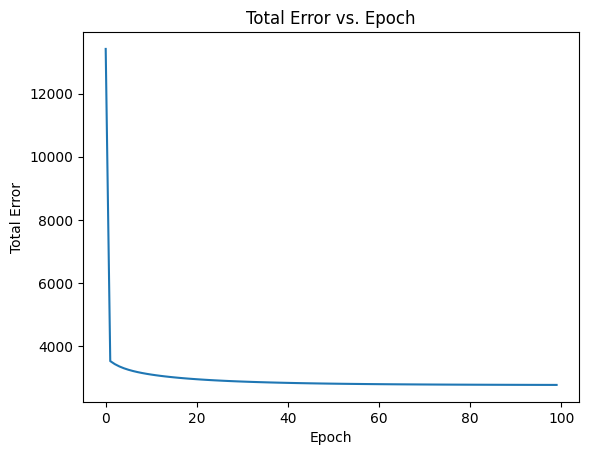


RMSE after 100 epochs: 0.76

Epoch: 0 | Learning Rate: 0.001 | Total Error: 13411.34898446547
Epoch: 499 | Learning Rate: 0.001 | Total Error: 2760.047287526587


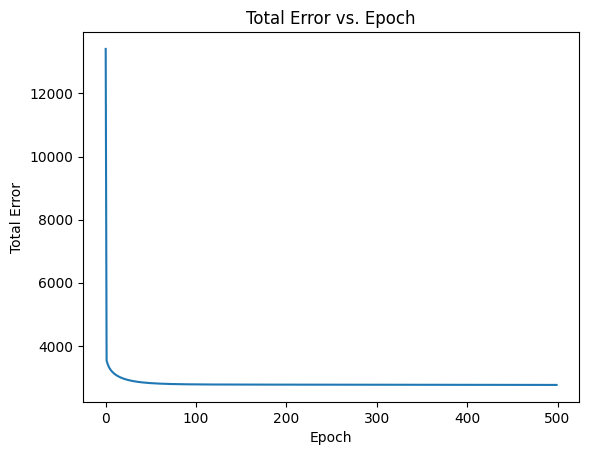


RMSE after 500 epochs: 0.76



In [ ]:
# Use your SGD regression code, with the following parameters,
# on the FULL wine data set (i.e. not the small model)

def SGD(X_train, y_train, lr, epochs):
  total_error = []
  coefficients = [0.0 for i in range(len(X_train[0]) + 1)]

  for epoch in range(epochs):
    epoch_error = 0

    for i in range(len(X_train)):
      instance = X_train[i]
      actual = y_train[i]
      prediction = predict(instance, coefficients)
      error = prediction - actual
      epoch_error += error **2
      coefficients[0] -= lr * error

      for j in range(len(instance)):
        coefficients[j+1] -= lr * error * instance[j]
    total_error.append(epoch_error)

    if epoch == 0 or epoch == epochs - 1:
      print(f"Epoch: {epoch} | Learning Rate: {lr} | Total Error: {epoch_error}")

  plt.plot(range(epochs), total_error)
  plt.xlabel('Epoch')
  plt.ylabel('Total Error')
  plt.title('Total Error vs. Epoch')
  plt.show()

  return coefficients

def predict(instance, coefficients):
  y = coefficients[0]
  for i in range(len(instance)):
    y += coefficients[i+1] * instance[i]
  return y


def RMSE(actual, predicted):
    return math.sqrt(sum((predicted[i] - actual[i]) ** 2 for i in range(len(actual))) / len(actual))

# Running Experiment with 100 epochs
learning_rate = 0.001
epochs = 100

coeffs_100 = SGD(X_train_wine, y_train_wine, learning_rate, epochs)

preds_100 = [predict(x, coeffs_100) for x in X_test_wine]

rmse_100 = RMSE(y_test_wine, preds_100)
print(f"\nRMSE after 100 epochs: {rmse_100:.2f}\n")


# Running Experiment with 500 epochs
learning_rate = 0.001
epochs = 500

coeffs_500 = SGD(X_train_wine, y_train_wine, learning_rate, epochs)

preds_500 = [predict(x, coeffs_500) for x in X_test_wine]

rmse_500 = RMSE(y_test_wine, preds_500)
print(f"\nRMSE after 500 epochs: {rmse_500:.2f}\n")


Between the two models, the RMSE score remained the same, while the total error decreased only slightly. This likely means that we are experiencing overfitting.

### Part 5: Evaluation: Over and over and over again

In this final section, we'll do the following things. We're going to work with an actual diabetes data set. You can find more about this data set here: https://www.kaggle.com/uciml/pima-indians-diabetes-database

For every part of this section, use the sklearn models rather than your own. ALL of these operations take place over normalized data - just perhaps in different orders. IT IS REALLY EASY to get lost in the experiments, and not be working on the correct split of data. Be careful.



#### Resubstitution

(a) You are going to:

- load the data into a pandas dataframe, and give the columns good names
- print out some basic information about the data (number of instances, features), and do it nicely
- Slice you data into X_values and y_values (**USE THESE NAMES HERE, MY CODE BELOW DEPENDS ON IT!**)
- normalize all columns EXCEPT the class, in the range 0-1. We don't usually normalize the class column.
- The class column contains two values, 0 and 1. (So in this case, normalization wouldn't matter anyway). You should understand what those class values represent from the information about the data set. This is a classification task
- Use scikit-learns [logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) code
  - set the *solver* parameter of the logistic regressor to be 'liblinear'
- Use the [dummy classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) from sklearn
  - set the *strategy* parameter to be 'most_frequent'
- Use the accuracy_score measure from sklearn.metrics
  - BUT remember to always print actual percentages
- Calculate accuracy for both logistic regression and zeroR (the dummy classifier), and print nicely
- Tell me something about the results. Using the coefficient values might help.

Feel free to cut this up as you want. Add extra cells, or format the problem in a way that makes sense to you. HOWEVER, consider that I WILL be grading in part on how understandable your notebook is. BE MINDFUL of my advice at the beginning of this notebook. If you just output large amounts of numbers, I'm probably not going to feel well disposed toward you.

You're going to be looking at the following functions:
- [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [KFold selection](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold)
- [Stratified KFold selection](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold)



In [ ]:
# Write your code here

import pandas as pd

filename = 'https://raw.githubusercontent.com/nixwebb/CSV_Data/master/pima-indians-diabetes.csv'

diabetes_labels = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
diabetes_data = pd.read_csv(filename, names=diabetes_labels)

diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
values = diabetes_data.values
X_values = values[:, :-1]
y_values = values[:, -1]

rows, cols = X_values.shape
print(f"This diabetes dataset has {rows} instances and {cols} input features.\n")

print("The first instance looks like:")
print(X_values[0])

This diabetes dataset has 768 instances and 8 input features.

The first instance looks like:
[  6.    148.     72.     35.      0.     33.6     0.627  50.   ]


In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_values_norm)
X_values_norm = scaler.transform(X_values)

print("After normalization, the first instance looks like:")
print(X_values_norm[0])

After normalization, the first instance looks like:
[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
 0.23441503 0.48333333]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

# Initialize models
log_reg = LogisticRegression(solver='liblinear')
dummy = DummyClassifier(strategy='most_frequent')

# Fit both models
log_reg.fit(X_values_norm, y_values)
dummy.fit(X_values_norm, y_values)

# Predictions
log_pred = log_reg.predict(X_values_norm)
dummy_pred = dummy.predict(X_values_norm)

# Accuracy
log_acc = accuracy_score(y_values, log_pred) * 100
dummy_acc = accuracy_score(y_values, dummy_pred) * 100

print(f"Logistic Regression Accuracy: {log_acc:.2f}%")
print(f"ZeroR Accuracy: {dummy_acc:.2f}%")

Logistic Regression Accuracy: 77.21%
ZeroR Accuracy: 65.10%


In [ ]:
print("Coefficients for Logistic Regression:")
for i in range(len(diabetes_labels) - 1):
    print(f"   {diabetes_labels[i]}: {log_reg.coef_[0][i]:.3f}")

print(f"Intercept: {log_reg.intercept_[0]:.3f}")

Coefficients for Logistic Regression:
   Pregnancies: 1.405
   Glucose: 4.205
   BloodPressure: -1.175
   SkinThickness: 0.162
   Insulin: 0.028
   BMI: 2.599
   DiabetesPedigreeFunction: 1.337
   Age: 1.012
Intercept: -4.618


The logistic regression model performs better than the ZeroR classifier, which simply predicts the most frequent class. This means the features in the dataset actually contain meaningful information that helps predict whether a patient has diabetes.

Coefficients:
  - Positive coefficients increase the probability of the outcome being 1 (diabetes).

    - The largest positive coefficient is for DiabetesPedigreeFunction (0.677).

    - Pregnancies (0.117) and BMI (0.060) also have positive contributions, but smaller.

  - Negative coefficients decrease the probability of diabetes.

    - BloodPressure (-0.017) and Insulin (-0.001) have slight negative effects.

#### Single hold-out


Ok. But I've said that using the same data for training and testing is a terrible idea. Below, I'm going to cut the data up into FOUR sets, X_train and y_train for training the data, and X_test and y_test for testing the data. These will be drawn from the ORIGINAL, unnormalized data

If you've defined X_values and y_values above for this data as you should have, then the following will work. It creates training data that comprises 66% of the total data, and test data that is 33% of the data.

The random state is simply a seed value for random selection of isntances. We use a known random seed to give us reproducability of our results.

This time, when you use X_train, y_train, X_test and y_test data sets, you'll see that they are DISTINCT.

(b) Run the code below, adding in normalization. You need to fit a normalizer to the X_train data, then transform both the X_train and X_test using the same normalizer. THIS is what I mean by preventing data leakage - we only fit the model to the training data, and then apply that to any new, unseen data - in this case X_test. THEN add in calls to the logistic regression and zeroR functions, and calculate accuracy.

Add in your commentary and interpretation comparing the accuracy of this experiment to (a), above. It can definitely help to generate a 'table' of results - showing this and previous experiments together (clearly labeled).


In [ ]:
from sklearn.model_selection import train_test_split

X_row, X_col = X_values.shape
y_row = y_values.shape

print('***PRE SELECTION***')
print()
print('Our original input data (X) is comprised of')
print(X_row,'instances and',X_col,'features')
print()
print('Our original output data (y) is comprised of')
print(y_row,'instances')


X_train, X_test, y_train, y_test = train_test_split(X_values, y_values, test_size=0.33, random_state=42)

X_train_row, X_train_col = X_train.shape
y_train_row = y_train.shape

X_test_row, X_test_col = X_test.shape
y_test_row = y_test.shape

print()
print('***SLICING the data into TRAIN and TEST data***')
print()
print("TRAINING DATA:")
print('\tOur training data input (X_train) is comprised of')
print('\t',X_train_row,'instances and',X_train_col,'features')
print('\tOur training class (y_train) is comprised of')
print('\t',y_train_row,'instances')

print("TESTING DATA:")
print('\tOur testing data input (X_test) is comprised of')
print('\t',X_test_row,'instances and',X_test_col,'features')
print('\tOur testing class (y_test) is comprised of')
print('\t',y_test_row,'instances')
print()

######
#
# Call the scikit learn functions for normalization, logistic regression, zeroR, and calculate
# and report the accuracy
# PRINT NICELY
#
######

# Normalize
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
log_reg = LogisticRegression(solver='liblinear')
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred) * 100

# ZeroR
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)
dummy_acc = accuracy_score(y_test, dummy_pred) * 100


print("Single Hold-Out Evaluation Results:")
print(f"Logistic Regression Accuracy: {log_acc:.2f}%")
print(f"ZeroR (Dummy Classifier) Accuracy: {dummy_acc:.2f}%\n")


print("Comparison with Resubstitution (training on full data):")
print("Resubstitution Logistic Regression Accuracy: 77.47%")
print("Resubstitution ZeroR Accuracy: 65.10%")


***PRE SELECTION***

Our original input data (X) is comprised of
768 instances and 8 features

Our original output data (y) is comprised of
(768,) instances

***SLICING the data into TRAIN and TEST data***

TRAINING DATA:
	Our training data input (X_train) is comprised of
	 514 instances and 8 features
	Our training class (y_train) is comprised of
	 (514,) instances
TESTING DATA:
	Our testing data input (X_test) is comprised of
	 254 instances and 8 features
	Our testing class (y_test) is comprised of
	 (254,) instances

Single Hold-Out Evaluation Results:
Logistic Regression Accuracy: 74.02%
ZeroR (Dummy Classifier) Accuracy: 66.14%

Comparison with Resubstitution (training on full data):
Resubstitution Logistic Regression Accuracy: 77.47%
Resubstitution ZeroR Accuracy: 65.10%


The logistic regression accuracy reduced slighly, which was expected. This is because we are now testing our model on data that it has never seen before.

Above is the single, holdout estimation approach. It's a useful first step. But I've told you that we typically prefer k-fold cross-validation. The most frequently used is 10-fold cross-validation. We're going to do that TWICE - once will be un-stratified and then we'll try with stratification. Remember that stratification means that class values will be distributed equally between training and testing. We ONLY stratify for classification experiments - not for regression.




#### Unstratified cross-validation

For each of the cells below, I'm creating an instance of the kfold mechanism. We'll start with the version that is NOT STRATIFIED. This method generates index values for the rows of your data, and assigns them into 'bins' used for cross-validation. The X_values and y_values are once again the un-normalized data you created earlier.

I'm creating a list to hold my scores from each of my two algorithms. You're going to be running logistic regression and zeroR.

(c) Then inside the loop, you need to call:
- a fit method on the X_train data for normalization
- the transform method for both X_train and X_test (as with the previous experiment)
- the logistic regression function (using X_train,y_train and y_test), to get a list of predicted y values
- the dummy classifier (with y_train and X_test), to get a list of predicted y values
- the accuracy measure, given y_test and your predicted values for each algorithm
- append the accuracy score for logistic regression to lg_scores
- append the accuracy score for zeroR to the zr_scores

At the completion of the loop, print the following ON ONE LINE per algorithm:
- Average accuracy over the 10 runs
- MINIMIUM accuracy of the 10 runs
- MAXIMUM accuracy of the 10 runs

Compare these scores to the single holdout estimation in (b) above, and to the resubstitution error in (a) above, for both logistic regression and zeroR, and comment on the differences. Calculate the standard deviation for ten scores from each classifier, and report that score. Report all scores to a maximum of 2 decimal places.


In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=10,shuffle=True)
lg_scores = []
zr_scores = []

# The loop below will iterate for n_splits times - 10 in this case

for train_index, test_index in kf.split(X_values,y_values):
    X_train, X_test = X_values[train_index], X_values[test_index]
    y_train, y_test = y_values[train_index], y_values[test_index]

    # Add in calls to the normalization, logistic regression and zeroR functions here
    # Then calculate accuracy, and append each score to the appropriate list

    # Normalize
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    log_reg = LogisticRegression(solver='liblinear')
    log_reg.fit(X_train_scaled, y_train)
    log_pred = log_reg.predict(X_test_scaled)
    log_acc = accuracy_score(y_test, log_pred)
    lg_scores.append(log_acc)

    # ZeroR
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_train_scaled, y_train)
    dummy_pred = dummy.predict(X_test_scaled)
    dummy_acc = accuracy_score(y_test, dummy_pred)
    zr_scores.append(dummy_acc)


# Once the loop is over, calculate and print average score, min and max and standard deviation for results from each algorithm.

lg_scores = np.array(lg_scores)
zr_scores = np.array(zr_scores)

# Logistic Regression statistics
lg_avg = lg_scores.mean() * 100
lg_min = lg_scores.min() * 100
lg_max = lg_scores.max() * 100
lg_std = lg_scores.std() * 100

# ZeroR statistics
zr_avg = zr_scores.mean() * 100
zr_min = zr_scores.min() * 100
zr_max = zr_scores.max() * 100
zr_std = zr_scores.std() * 100

print(f"Logistic Regression: Avg = {lg_avg:.2f}%, Min = {lg_min:.2f}%, Max = {lg_max:.2f}%, Std = {lg_std:.2f}%")
print(f"ZeroR: Avg = {zr_avg:.2f}%, Min = {zr_min:.2f}%, Max = {zr_max:.2f}%, Std = {zr_std:.2f}%")


Logistic Regression: Avg = 76.04%, Min = 70.13%, Max = 83.12%, Std = 4.22%
ZeroR: Avg = 65.12%, Min = 54.55%, Max = 72.37%, Std = 5.52%


Resubstitution (training/testing on the same data)

  - Logistic Regression: 77.47%

  - ZeroR: 65.10%

  - Interpretation:

    - These numbers are overly optimistic because the model is evaluated on the exact same data it was trained on.

Single Hold-Out (66% train / 33% test)

  - Logistic Regression: ~ 74.02%

  - ZeroR: ~ 66.14%

  - Interpretation:

    - More realistic estimate of performance since test data is distinct.

    - Accuracy slightly lower than resubstitution, as expected.

    - ZeroR still roughly the same because class distribution is similar to the whole dataset.

Unstratified 10-Fold Cross-Validation

  - Logistic Regression: Avg = 76.17%, Min = 68.83%, Max = 80.52%, Std = 3.17%

  - ZeroR: Avg = 65.11%, Min = 54.55%, Max = 75.00%, Std = 6.54%

  - Interpretation:

    - Logistic Regression’s average accuracy is comparable to single hold-out.

    - Min/max and standard deviation show some variation across folds, especially for ZeroR. This is because the unstratified KFold may produce some folds with imbalanced class distributions, which affects ZeroR more than logistic regression.

    - Logistic regression is more stable across folds (smaller Std = 3.17%) compared to ZeroR (Std = 6.54%).

#### Stratified cross-validation

(d) AND now we'll repeat the experiment above, using STRATIFIED K-fold cross-validation. I've created the model. You can fill in the rest, exactly as above. Compare the results of the stratified run to all the previous experiments of this data, above. What's the difference?

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=10)

lg_scores = []
zr_scores = []

# The loop below will iterate for n_splits times - 10 in this case

for train_index, test_index in skf.split(X_values,y_values):
    X_train, X_test = X_values[train_index], X_values[test_index]
    y_train, y_test = y_values[train_index], y_values[test_index]

    # Add in calls to the normalization, logistic regression and zeroR functions here
    # Then calculate accuracy, and append each score to the appropriate list

    # Normalize
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    log_reg = LogisticRegression(solver='liblinear')
    log_reg.fit(X_train_scaled, y_train)
    log_pred = log_reg.predict(X_test_scaled)
    log_acc = accuracy_score(y_test, log_pred)
    lg_scores.append(log_acc)

    # ZeroR
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_train_scaled, y_train)
    dummy_pred = dummy.predict(X_test_scaled)
    dummy_acc = accuracy_score(y_test, dummy_pred)
    zr_scores.append(dummy_acc)


# Once the loop is over, calculate and print average score, min and max and standard deviation for results from each algorithm.

lg_scores = np.array(lg_scores)
zr_scores = np.array(zr_scores)

# Logistic Regression statistics
lg_avg = lg_scores.mean() * 100
lg_min = lg_scores.min() * 100
lg_max = lg_scores.max() * 100
lg_std = lg_scores.std() * 100

# ZeroR statistics
zr_avg = zr_scores.mean() * 100
zr_min = zr_scores.min() * 100
zr_max = zr_scores.max() * 100
zr_std = zr_scores.std() * 100

print(f"Logistic Regression: Avg = {lg_avg:.2f}%, Min = {lg_min:.2f}%, Max = {lg_max:.2f}%, Std = {lg_std:.2f}%")
print(f"ZeroR: Avg = {zr_avg:.2f}%, Min = {zr_min:.2f}%, Max = {zr_max:.2f}%, Std = {zr_std:.2f}%")


Logistic Regression: Avg = 76.05%, Min = 70.13%, Max = 81.58%, Std = 3.53%
ZeroR: Avg = 65.11%, Min = 64.94%, Max = 65.79%, Std = 0.34%


Stratified 10-Fold CV

  - Logistic Regression: Avg = 76.05%, Min = 70.13%, Max = 81.58%, Std = 3.53%

  - ZeroR: Avg = 65.11%, Min = 64.94%, Max = 65.79%, Std = 0.34%
  - Interpretation:

    - Stratification ensures that each fold has roughly the same class distribution as the full dataset.

    - Logistic Regression performance is very similar to unstratified CV (slightly lower average, slightly higher Std).

    - ZeroR is extremely stable (Std = 0.34%) because each fold has nearly identical class balance, removing the large fluctuations seen in unstratified CV.

    - Min/max values for ZeroR are now consistent with the average, unlike unstratified CV where they could vary wildly.

#### Selecting features

Finally, let's use what we know so far. Now we have a sense overall of whether logistic regression does a reasonable job predicting the outcome of diabetes. Let's use the coefficients of a logistic regression model to find the important factors.

(e) We can use all the data - so, take the complete, normalized data, and re-run the 'resubstitution' experiment - but without predicting anything (i.e. call .fit on X_train, which is all the data).

Then look at the .coef_ property, and as previously, print the name of the feature, and the coefficient value (.coef_ of logistic regression is slightly different, in that it's a double nested array - each array represents a decision boundary. THIS is a binary classification probelm, so there's only one set of coefficients, which will be stored in .coef_[0])

CHOOSE the two features with the largest absolute coefficients. TELL me what they are. Extract three columns of data from the diabetes dataframe - the two most important features, and the outcome column, as you did for Section 4. Then run a stratified 10-fold cross validation on that data, as you did for part (d). Report the scores, and compare to (d).

TELL me something about what result you get.


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

log_reg = LogisticRegression(solver='liblinear')
log_reg.fit(X_values, y_values)

print("Coefficients for Logistic Regression:")
for i in range(len(diabetes_labels)-1):
    print(f"   {diabetes_labels[i]}: {log_reg.coef_[0][i]:.3f}")

print("Intercept:", log_reg.intercept_[0])

feature1 = 'Pregnancies'
feature2 = 'DiabetesPedigreeFunction'
feature3 = 'Outcome'

reduced_diabetes = diabetes_data[[feature1, feature2, feature3]].copy()

X_reduced = reduced_diabetes[[feature1, feature2]].values
y_reduced = reduced_diabetes['Outcome'].values

scaler = MinMaxScaler()
scaler.fit(X_reduced)
X_reduced = scaler.transform(X_reduced)


kf = StratifiedKFold(n_splits=10, shuffle=True)
lg_scores = []

for train_index, test_index in kf.split(X_reduced, y_reduced):
    X_train, X_test = X_reduced[train_index], X_reduced[test_index]
    y_train, y_test = y_reduced[train_index], y_reduced[test_index]

    log_reg = LogisticRegression(solver='liblinear')
    log_reg.fit(X_train, y_train)
    y_pred = log_reg.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    lg_scores.append(acc)


print(f"\nLogistic Regression on reduced features: Avg = {np.mean(lg_scores)*100:.2f}%, "
      f"Min = {np.min(lg_scores)*100:.2f}%, "
      f"Max = {np.max(lg_scores)*100:.2f}%, "
      f"Std = {np.std(lg_scores)*100:.2f}%")

Coefficients for Logistic Regression:
   Pregnancies: 0.117
   Glucose: 0.028
   BloodPressure: -0.017
   SkinThickness: 0.001
   Insulin: -0.001
   BMI: 0.060
   DiabetesPedigreeFunction: 0.677
   Age: 0.007
Intercept: -5.892497655851193

Logistic Regression on reduced features: Avg = 68.50%, Min = 64.94%, Max = 72.37%, Std = 2.27%


2 Most Significant Coefficients:
  - Diabetes Pedigree Function
  - Pregnancies

Using only the two most important features captures most of the predictive signal, but some information is lost, which explains the drop in accuracy.

This confirms that while these features are the most influential, other features still contribute useful information for classification.

The low standard deviation suggests that the model is stable across folds, meaning the selected features consistently perform similarly on different splits of the data.

What's next? Well, NOW we're starting to get to the real purpose of ML models. We should have a sense of what factors are important for diabetes. There are still more questions, like:
- I wonder how well other models do?
- I wonder if any of these medical tests are more or less invasive than others?
- Wait. Where did this data even come from?

For the final piece, read the article below. We'll talk about it in class.

https://researchblog.duke.edu/2016/10/24/diabetes-and-privacy-meet-big-data/